### 1. Importing Dataset and Libraries

In [135]:
# 1. Importing And Loading Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
import math

from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor,plot_importance
from lightgbm import LGBMRegressor,plot_importance as lgbm_plot_importance

warnings.filterwarnings('ignore')
train_df=pd.read_csv('train.csv',encoding='utf-8')
test_df=pd.read_csv('test.csv',encoding='utf-8')
stores_df=pd.read_csv('stores.csv',encoding='utf-8')
features_df=pd.read_csv('features.csv',encoding='utf-8')

df_original=train_df.merge(stores_df,on='Store',how='left')
df_original=df_original.merge(features_df,on=['Store','Date'],how='left')
df_original=df_original.sort_values(by=['Store','Date'])
df_original=df_original.reset_index(drop=True,inplace=False)
df_original['Date']=pd.to_datetime(df_original['Date'])
df=df_original.copy()

#only showing first 5 rows
df.head()


,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2,2010-02-05,50605.27,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
2,1,3,2010-02-05,13740.12,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
3,1,4,2010-02-05,39954.04,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
4,1,5,2010-02-05,32229.38,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False


### 2. Cleaning Walmart Dataset

In [136]:
#Checking basic info
df.info()
print("Shape of Forest dataset is:",df.shape)
print("\nTarget variable distribution is:")
print(df['Weekly_Sales'].value_counts())
print(df['Weekly_Sales'].describe())

#Separating numeric and categorical columns
numeric_columns=df.select_dtypes(include=['int64','float64']).columns.tolist()
string_columns=df.select_dtypes(include=['object']).columns.tolist()
print("\nNumeric Columns:",numeric_columns)
print("Categorical Columns:",string_columns)

#Checking missing values
print("\nMissing Values per Column in the Forest Dataset:")
print(df.isnull().sum())

#Checking unique counts of numerical columns
if numeric_columns:
    print("\nUnique value counts (numerical columns):")
    print(df[numeric_columns].nunique())

#Checking unique counts of categorical columns
if string_columns:
    print("\nUnique value counts (categorical columns):")
    print(df[string_columns].nunique())

#Handling missing values
df[numeric_columns]=df[numeric_columns].apply(lambda x:x.fillna(x.mean()))
if string_columns:
    df[string_columns]=df[string_columns].apply(lambda x:x.fillna(x.mode()[0]))

# Dropping useless columns (only 1 unique value)
df=df.drop(columns=df.columns[df.nunique()==1])

# Resetting index after cleaning in same dataset
df.reset_index(drop=True,inplace=True)

#Shape of dataset after cleaning
print("\nShape after cleaning:",df.shape)

#Quick descriptive stats for dataset
print("\nStatistical summary of numeric features:")
print(df[numeric_columns].describe().T)

#Quantile distribution for numeric columns
print("\nQuantile distribution of numeric columns:")
print(df[numeric_columns].quantile([0.25,0.5,0.75]).T)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday_x   421570 non-null  bool          
 5   Type          421570 non-null  object        
 6   Size          421570 non-null  int64         
 7   Temperature   421570 non-null  float64       
 8   Fuel_Price    421570 non-null  float64       
 9   MarkDown1     150681 non-null  float64       
 10  MarkDown2     111248 non-null  float64       
 11  MarkDown3     137091 non-null  float64       
 12  MarkDown4     134967 non-null  float64       
 13  MarkDown5     151432 non-null  float64       
 14  CPI           421570 non-null  float64       
 15  Unemployment  421

### 3. Visualizing Walmart Dataset

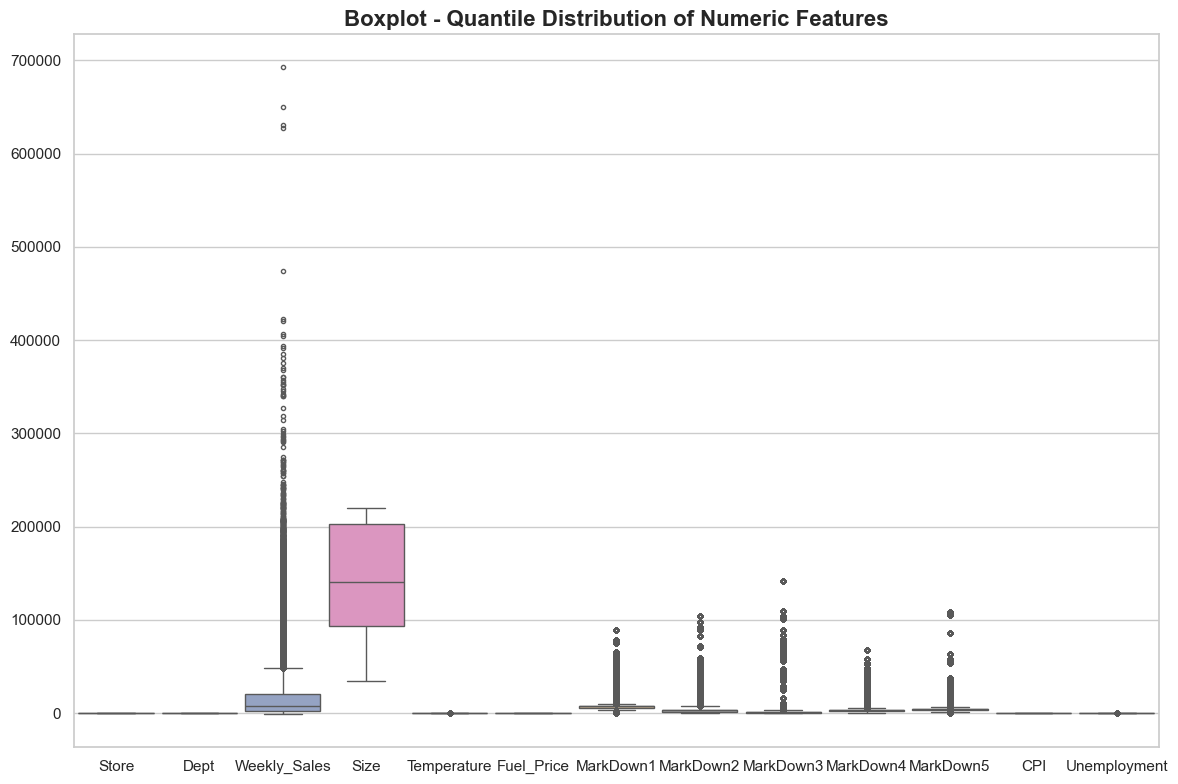

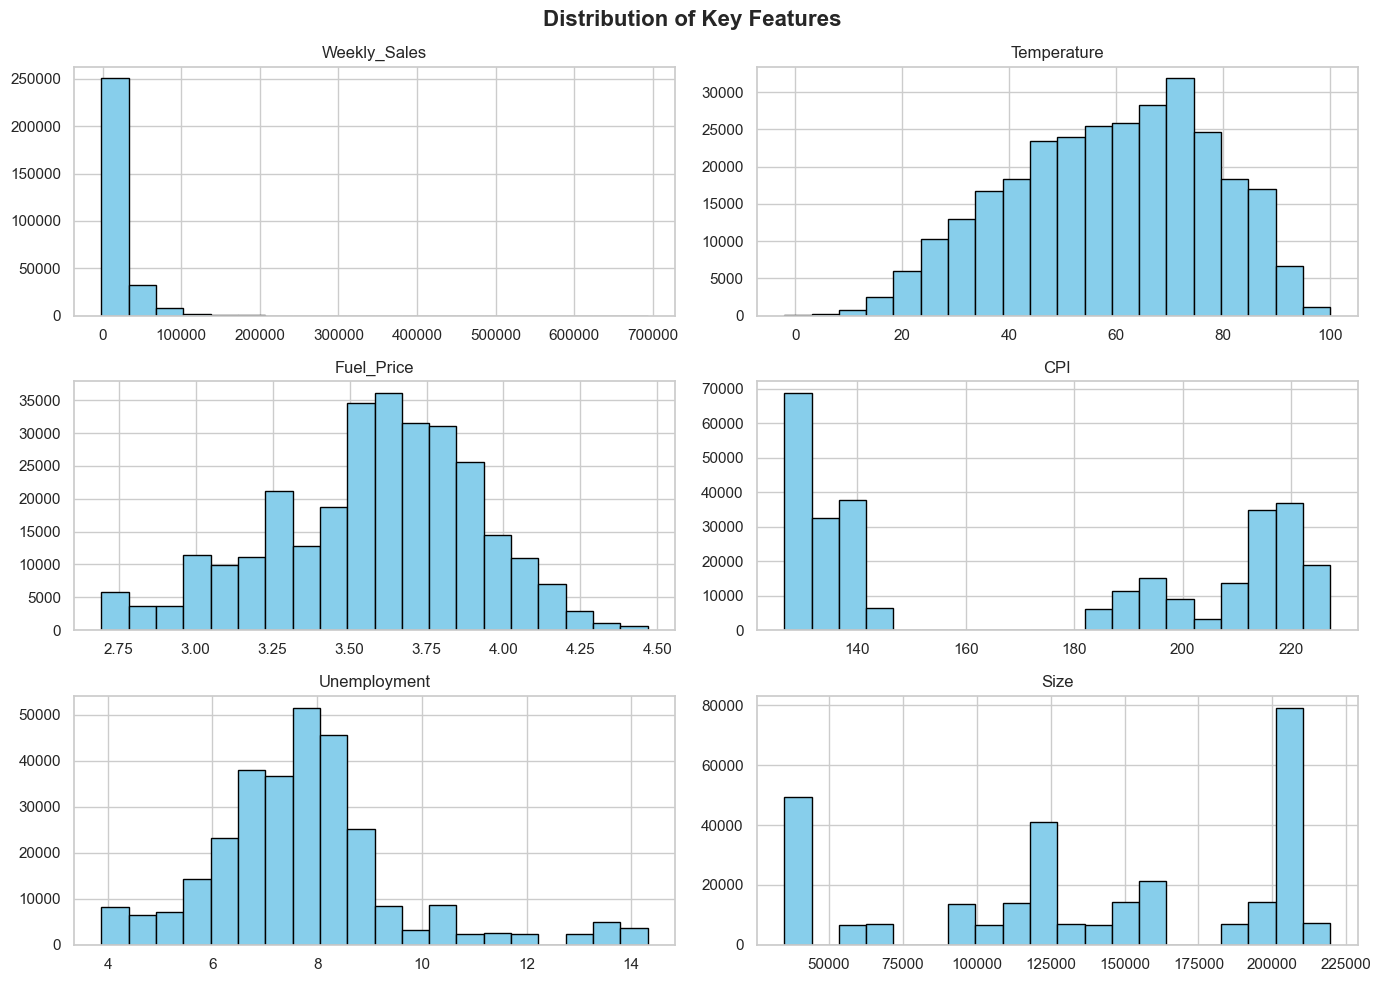


Applied Ordinal Encoding on Categorical columns.


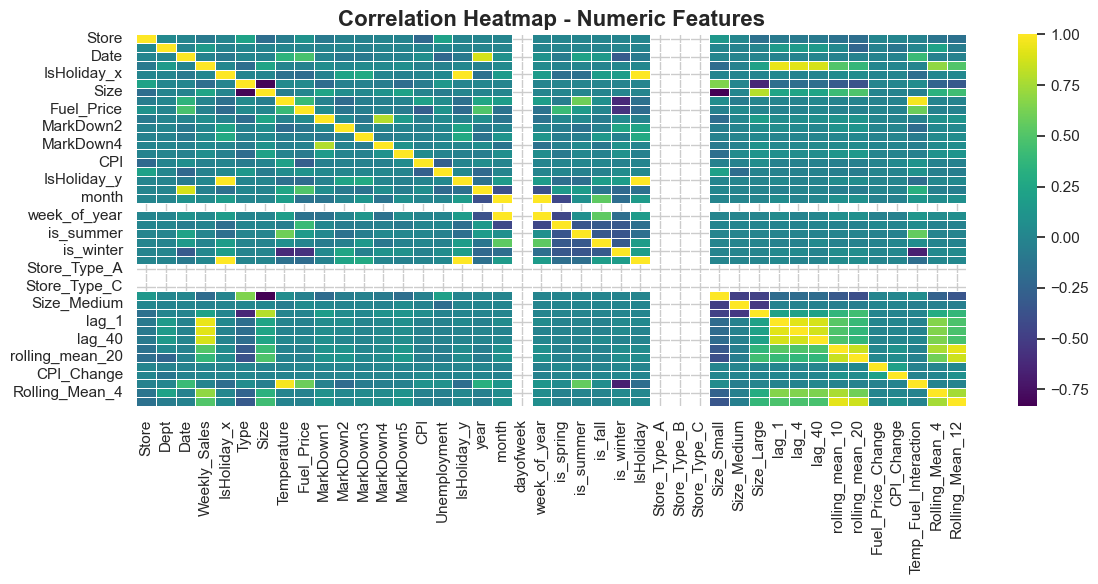

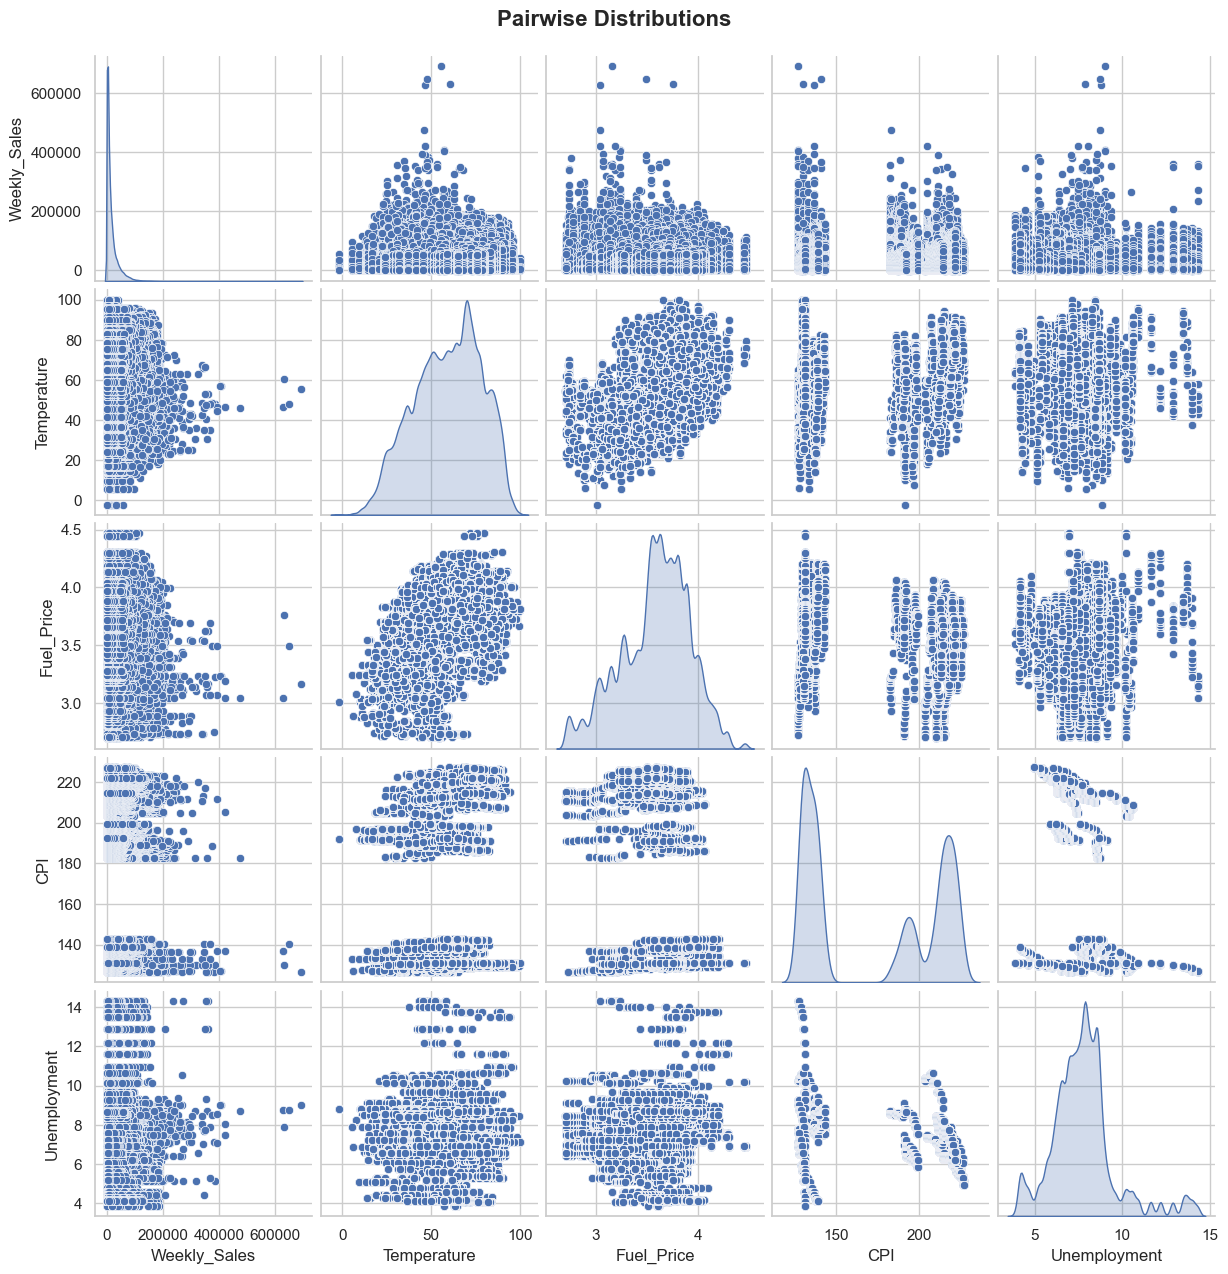

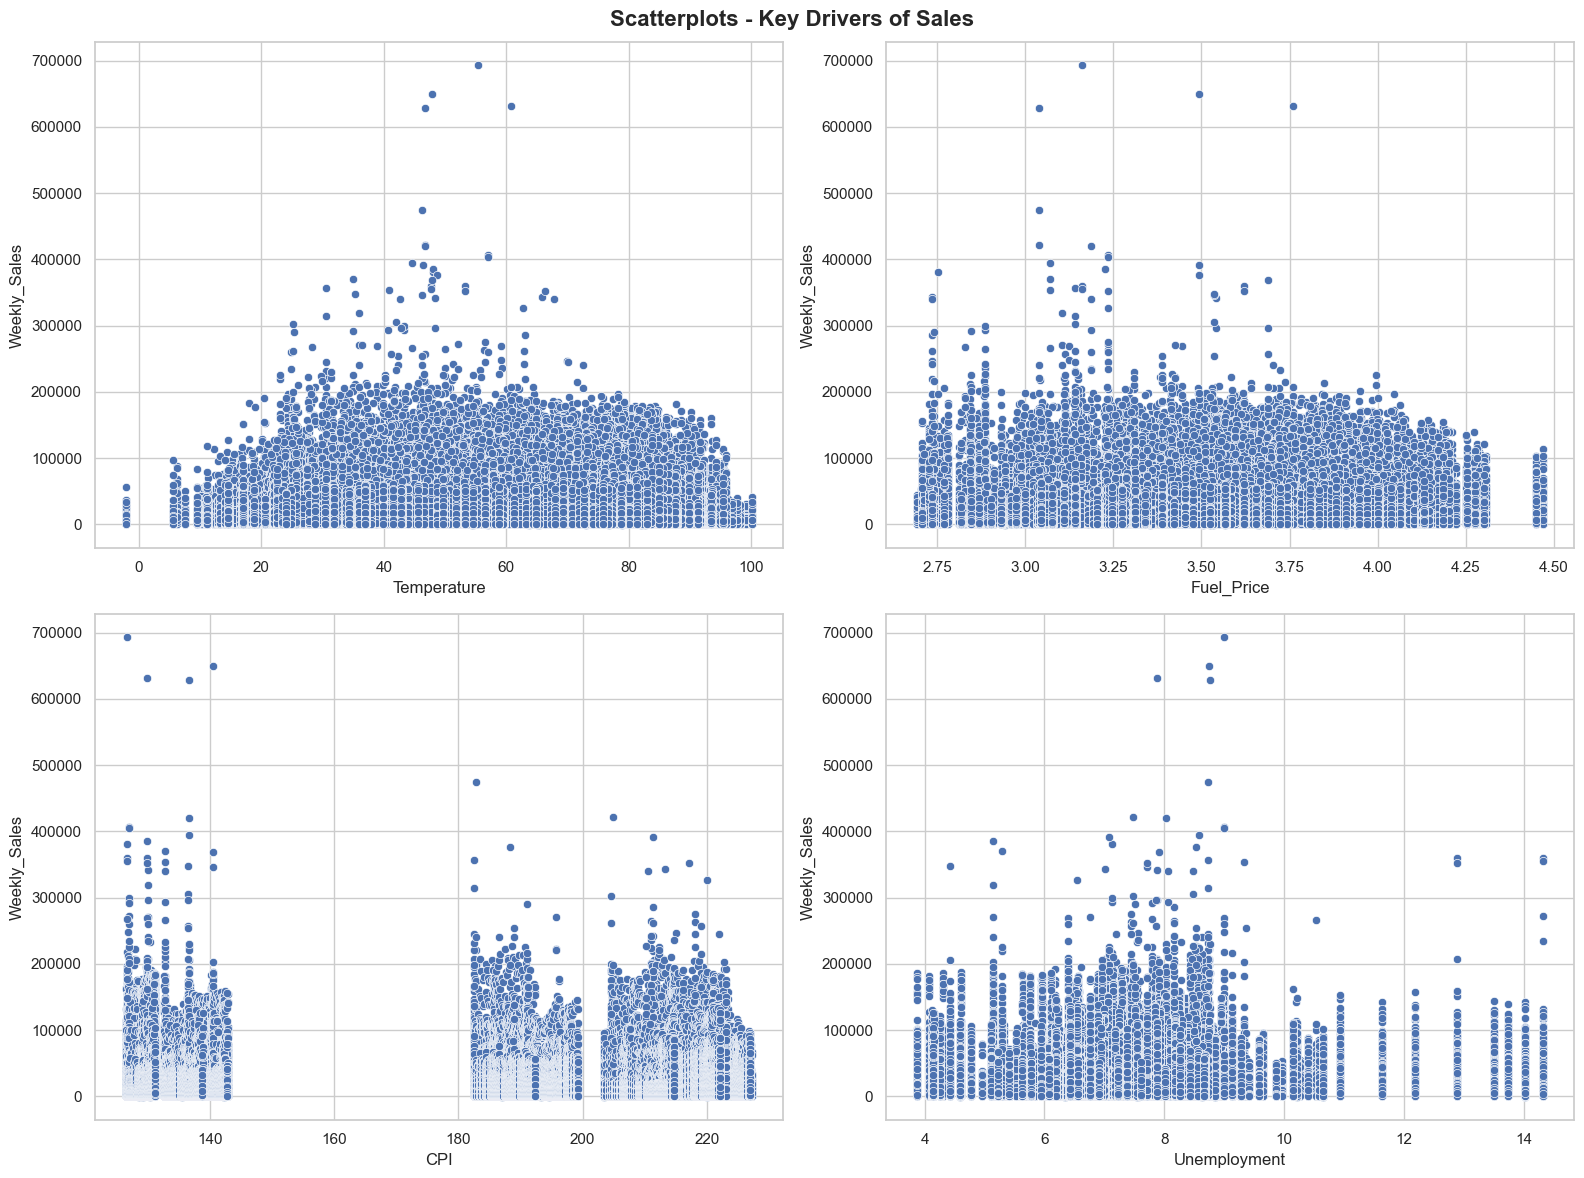

In [148]:
#Boxplots
plt.figure(figsize=(12,8))
sns.boxplot(data=df[numeric_columns],orient='v',palette='Set2',width=0.9,fliersize=3,linewidth=1)
plt.title("Boxplot - Quantile Distribution of Numeric Features",fontsize=16,fontweight="bold")
plt.tight_layout()
plt.show()

#Histograms
columns_visualize=['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment','Size']
columns_visualize=[col for col in columns_visualize if col in numeric_columns]
df[columns_visualize].hist(figsize=(14,10),bins=20,edgecolor='black',color='skyblue')
plt.suptitle("Distribution of Key Features",fontsize=16,fontweight="bold")
plt.tight_layout()
plt.show()

#Correlation Heatmap
if string_columns:
    encoder=OrdinalEncoder()
    df[string_columns]=encoder.fit_transform(df[string_columns])
    print("\nApplied Ordinal Encoding on Categorical columns.")
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(),annot=False,cmap="viridis",linewidth=0.4)
plt.title("Correlation Heatmap - Numeric Features",fontsize=16,fontweight="bold")
plt.tight_layout()
plt.show()

# Pairplots
sns.pairplot(df[['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']],diag_kind="kde",palette="Set1")
plt.suptitle("Pairwise Distributions",y=1.02,fontsize=16,fontweight="bold")
plt.show()

# Scatter subplots
fig,axes=plt.subplots(2,2,figsize=(16,12))
sns.scatterplot(x="Temperature",y="Weekly_Sales",data=df,ax=axes[0,0])
sns.scatterplot(x="Fuel_Price",y="Weekly_Sales",data=df,ax=axes[0,1])
sns.scatterplot(x="CPI",y="Weekly_Sales", data=df,ax=axes[1,0])
sns.scatterplot(x="Unemployment",y="Weekly_Sales",data=df,ax=axes[1,1])
plt.suptitle("Scatterplots - Key Drivers of Sales",fontsize=16,fontweight="bold")
plt.tight_layout()
plt.show()


### 4. Feature Engineering

In [138]:
# Time features
df['year']=df['Date'].dt.year
df['month']=df['Date'].dt.month
df['dayofweek']=df['Date'].dt.dayofweek
df['week_of_year']=df['Date'].dt.isocalendar().week.astype(int)

# Seasonal encoding
df['is_spring']=((df['month']>=3)&(df['month']<=5)).astype(int)
df['is_summer']=((df['month']>=6)&(df['month']<=8)).astype(int)
df['is_fall']=((df['month']>=9)&(df['month']<=11)).astype(int)
df['is_winter']=((df['month']==12)|(df['month']<=2)).astype(int)

# Holiday encoding
df['IsHoliday']=df['IsHoliday_y'].astype(int)

# Store encoding
df['Store_Type_A']=(df['Type']=='A').astype(int)
df['Store_Type_B']=(df['Type']=='B').astype(int)
df['Store_Type_C']=(df['Type']=='C').astype(int)

# Size bins 
q33,q67=df['Size'].quantile([0.33,0.67])
df['Size_Small']=(df['Size']<q33).astype(int)
df['Size_Medium']=((df['Size']>=q33)&(df['Size']<q67)).astype(int)
df['Size_Large']=(df['Size']>=q67).astype(int)

# Lag/Rolling Sales
df['lag_1']=df.groupby(['Store','Dept'])['Weekly_Sales'].shift(1)
df['lag_4']=df.groupby(['Store','Dept'])['Weekly_Sales'].shift(4)
df['lag_40']=df.groupby(['Store','Dept'])['Weekly_Sales'].shift(40)
df['rolling_mean_10']=df.groupby(['Store','Dept'])['Weekly_Sales'].shift(1).rolling(window=10).mean()
df['rolling_mean_20']=df.groupby(['Store','Dept'])['Weekly_Sales'].shift(1).rolling(window=20).mean()

# Deltas & interactions (This to that comparison)
df['Fuel_Price_Change']=df.groupby('Store')['Fuel_Price'].diff()
df['CPI_Change']=df.groupby('Store')['CPI'].diff()
df['Temp_Fuel_Interaction']=df['Temperature']*df['Fuel_Price']

# Drop NA from lag/rolling
df.dropna(inplace=True)
df.reset_index(drop=True,inplace=True)

print("Shape after feature engineering:",df.shape)
print("\nColumns after feature engineering:",df.columns.tolist())
print(df.head(100))

Shape after feature engineering: (294513, 40)

Columns after feature engineering: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y', 'year', 'month', 'dayofweek', 'week_of_year', 'is_spring', 'is_summer', 'is_fall', 'is_winter', 'IsHoliday', 'Store_Type_A', 'Store_Type_B', 'Store_Type_C', 'Size_Small', 'Size_Medium', 'Size_Large', 'lag_1', 'lag_4', 'lag_40', 'rolling_mean_10', 'rolling_mean_20', 'Fuel_Price_Change', 'CPI_Change', 'Temp_Fuel_Interaction']
    Store  Dept       Date  Weekly_Sales  IsHoliday_x  Type    Size  \
0       1     1 2010-11-12      19549.39        False   0.0  151315   
1       1     2 2010-11-12      43194.49        False   0.0  151315   
2       1     3 2010-11-12       9146.77        False   0.0  151315   
3       1     4 2010-11-12      35008.03        False   0.0  151315   
4       1     5 2010-11-12      

### 5. Visualizing Dataset After Feature Engineering

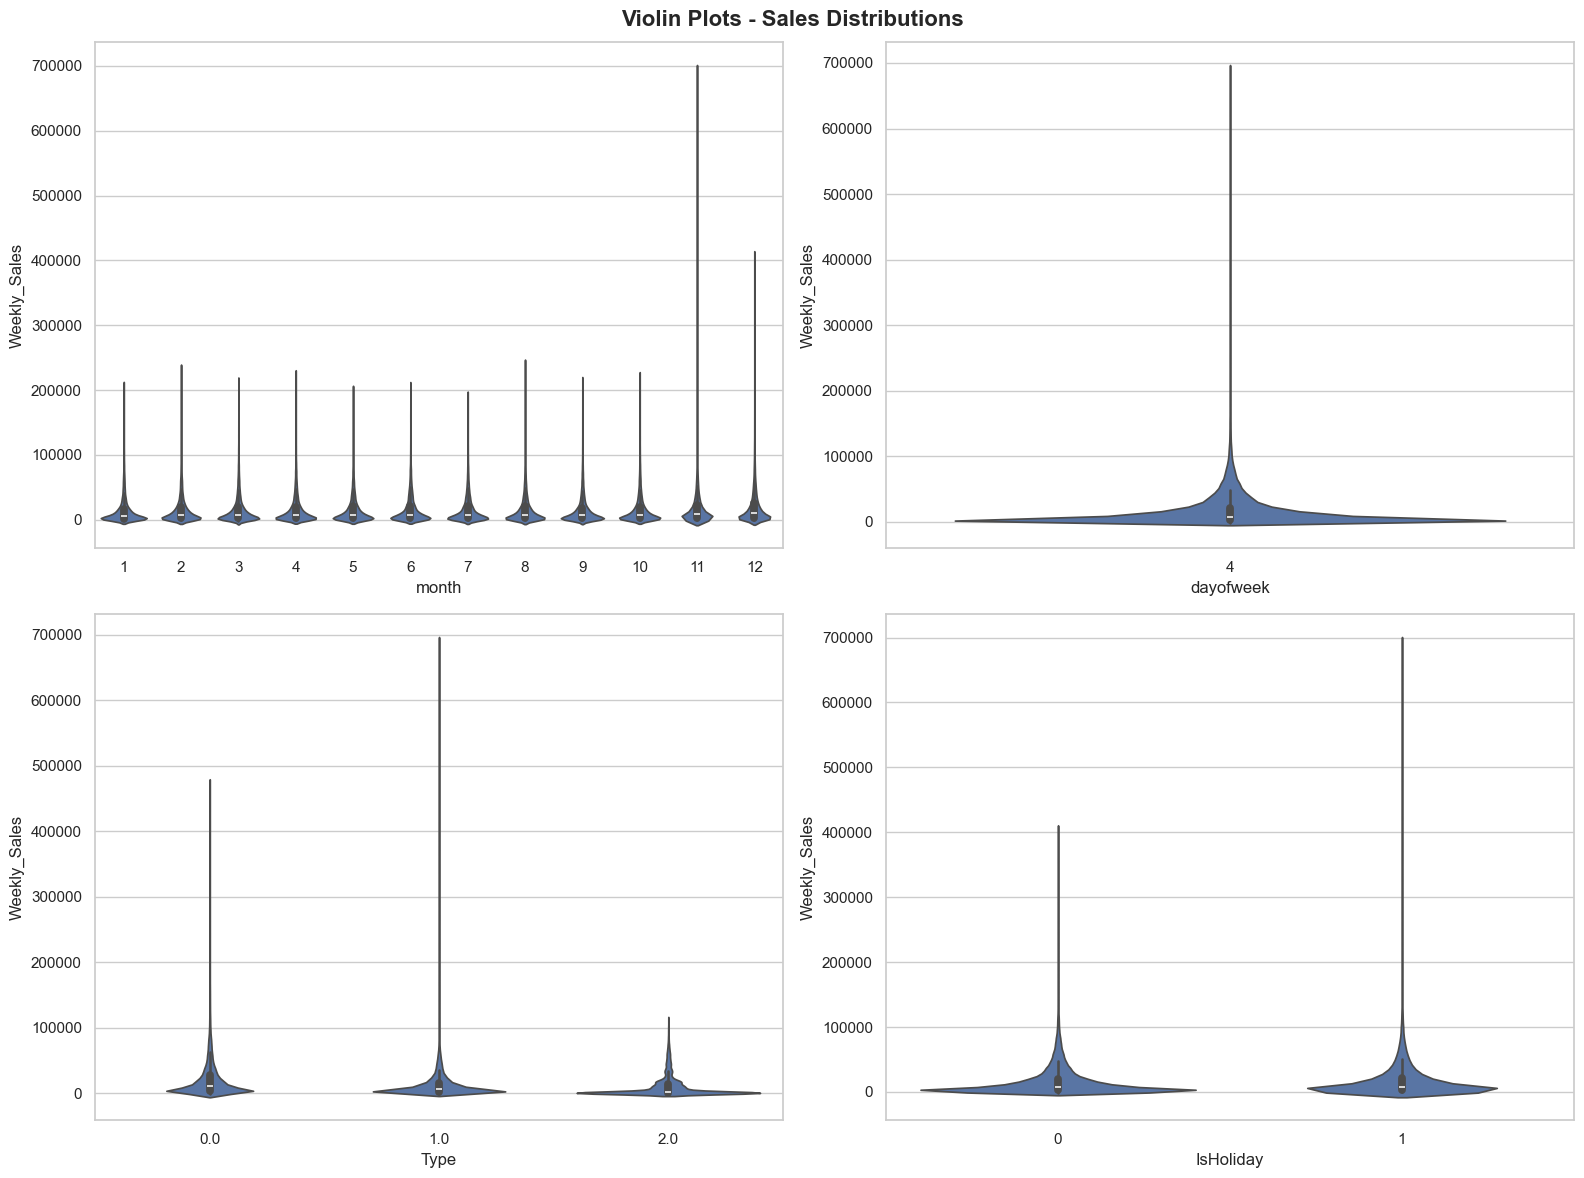

In [146]:
# Violin plots
fig, axes=plt.subplots(2,2,figsize=(16,12))
sns.violinplot(x="month",y="Weekly_Sales",data=df,ax=axes[0,0])
sns.violinplot(x="dayofweek",y="Weekly_Sales",data=df,ax=axes[0,1])
sns.violinplot(x="Type",y="Weekly_Sales",data=df,ax=axes[1,0])
sns.violinplot(x="IsHoliday",y="Weekly_Sales",data=df,ax=axes[1,1])
plt.suptitle("Violin Plots - Sales Distributions",fontsize=16,fontweight="bold")
plt.tight_layout()
plt.show()

### 6. Training Models

In [ ]:
x=df.drop(["Weekly_Sales","Date","Type"],axis=1)
y=df["Weekly_Sales"]
x_train,x_test, y_train, y_test=train_test_split(x,y,test_size=0.25,random_state=42)

# for rand forest
randf=RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1).fit(x_train,y_train)
y_pred_randf=randf.predict(x_test)
print(f"\n Random Forest Metrics:")
print(f"\n Random Forest RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_randf)))
print(f"\n Random Forest MAE:",mean_absolute_error(y_test,y_pred_randf))
print(f"\n Random Forest R2 SCORE:",r2_score(y_test,y_pred_randf))

# for linear regression
lr=LinearRegression().fit(x_train,y_train)
y_pred_lr=lr.predict(x_test)
print(f"\n Linear Regression Metrics:")
print(f"\n Linear Regression RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_lr)))
print(f"\n Linear Regression MAE:",mean_absolute_error(y_test,y_pred_lr))
print(f"\n Linear Regression R2 SCORE:",r2_score(y_test,y_pred_lr))

# for xgb 
xgb=XGBRegressor(n_estimators=100,learning_rate=0.1,random_state=42,n_jobs=-1)
xgb=xgb.fit(x_train,y_train)
y_pred_xgb=xgb.predict(x_test)
print(f"\n XGB Metrics:")
print(f"\n XGB RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_xgb)))
print(f"\n XGB MAE:",mean_absolute_error(y_test,y_pred_xgb))
print(f"\n XGB R2 SCORE:",r2_score(y_test,y_pred_xgb))

#for lgbm
lgbm=LGBMRegressor(n_estimators=100,learning_rate=0.1,random_state=42,n_jobs=-1)
lgbm=lgbm.fit(x_train,y_train)
y_pred_lgbm=lgbm.predict(x_test)
print(f"\n LGBM Metrics:")
print(f"\n LGBM RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_lgbm)))
print(f"\n LGBM MAE:",mean_absolute_error(y_test,y_pred_lgbm))
print(f"\n LGBM R2 SCORE:",r2_score(y_test,y_pred_lgbm))



 Random Forest Metrics:

 Random Forest RMSE: 5071.654158333954

 Random Forest MAE: 1679.825943595594

 Random Forest R2 SCORE: 0.9528886925817084

 Linear Regression Metrics:

 Linear Regression RMSE: 7154.730002088551

 Linear Regression MAE: 2400.2253803630324

 Linear Regression R2 SCORE: 0.9062411236402016

 XGB Metrics:

 XGB RMSE: 4194.232430616991

 XGB MAE: 1659.7703743697577

 XGB R2 SCORE: 0.9677796033117145
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015532 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4563
[LightGBM] [Info] Number of data points in the train set: 220884, number of used features: 33
[LightGBM] [Info] Start training from score 16436.419493

 LGBM Metrics:

 LGBM RMSE: 4117.630679465434

 LGBM MAE: 1677.4223308661037

 LGBM R2 SCORE: 0.9689457762928709


### 8. Feature Importance

                  Columns  Importance
29                  lag_1    0.810066
30                  lag_4    0.127107
17           week_of_year    0.011577
31                 lag_40    0.010778
8               MarkDown3    0.006557
32        rolling_mean_10    0.004821
1                    Dept    0.003866
11                    CPI    0.002504
5              Fuel_Price    0.002498
33        rolling_mean_20    0.002440
12           Unemployment    0.002088
6               MarkDown1    0.001749
4             Temperature    0.001712
36  Temp_Fuel_Interaction    0.001670
9               MarkDown4    0.001255
3                    Size    0.001244
0                   Store    0.001129
10              MarkDown5    0.001126
7               MarkDown2    0.000997
15                  month    0.000671


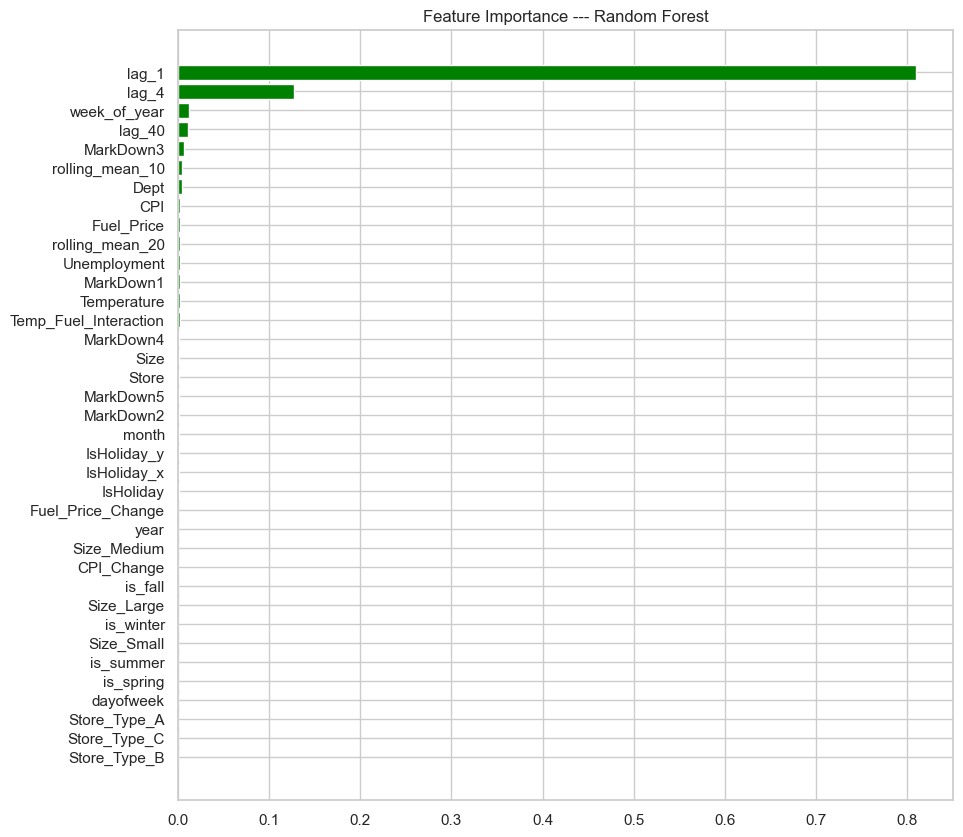

                  Columns   Importance
34      Fuel_Price_Change  4001.132665
35             CPI_Change  3940.222108
15                  month  1051.125258
20                is_fall   530.314131
18              is_spring   458.397244
17           week_of_year   199.322089
19              is_summer    79.889381
14                   year    68.388460
28             Size_Large    36.594915
4             Temperature    28.937099
22              IsHoliday    25.573676
13            IsHoliday_y    25.573676
2             IsHoliday_x    25.573676
27            Size_Medium    21.451068
26             Size_Small    15.143846
36  Temp_Fuel_Interaction     9.814420
21              is_winter     7.972494
5              Fuel_Price     5.313755
1                    Dept     4.363236
12           Unemployment     3.447270


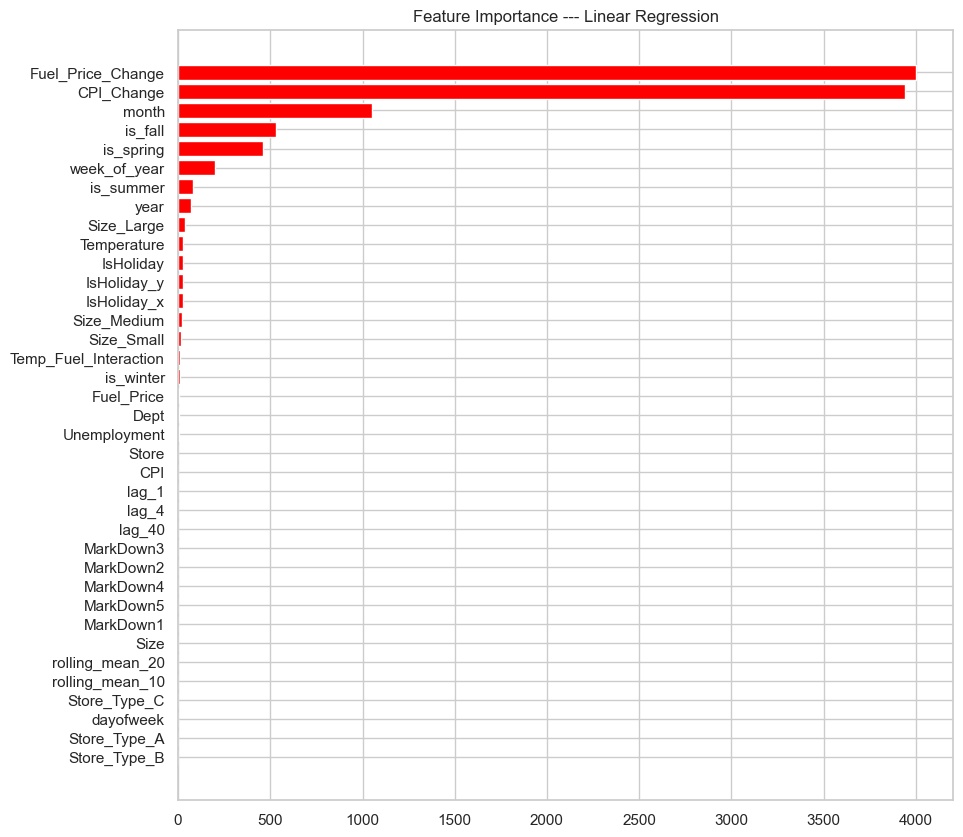

            Columns  Importance
29            lag_1    0.651857
30            lag_4    0.141271
14             year    0.037082
2       IsHoliday_x    0.019769
8         MarkDown3    0.016663
17     week_of_year    0.014017
32  rolling_mean_10    0.013942
31           lag_40    0.013520
1              Dept    0.009857
15            month    0.008692
6         MarkDown1    0.007577
12     Unemployment    0.007515
11              CPI    0.006969
5        Fuel_Price    0.005144
20          is_fall    0.004869
10        MarkDown5    0.004533
21        is_winter    0.004519
0             Store    0.003956
9         MarkDown4    0.003689
7         MarkDown2    0.003631


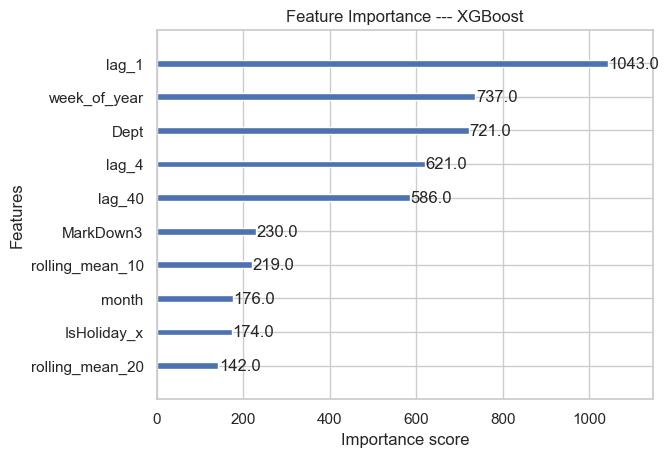

            Columns  Importance
29            lag_1         502
17     week_of_year         444
1              Dept         378
30            lag_4         306
31           lag_40         291
8         MarkDown3         154
15            month         119
32  rolling_mean_10         103
2       IsHoliday_x          91
33  rolling_mean_20          80
9         MarkDown4          63
5        Fuel_Price          50
12     Unemployment          47
4       Temperature          46
6         MarkDown1          43
10        MarkDown5          42
3              Size          38
7         MarkDown2          35
35       CPI_Change          33
11              CPI          32


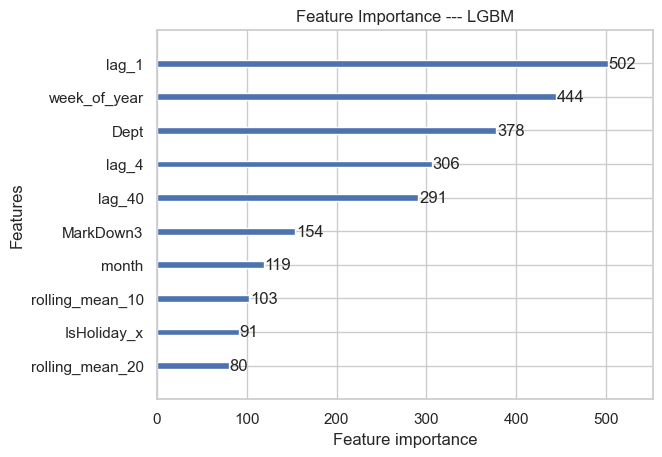

In [141]:
### for random forest
feat_imp_randf_dataset=pd.DataFrame({'Columns':x.columns,'Importance':randf.feature_importances_})
print(feat_imp_randf_dataset.sort_values(by='Importance',ascending=False).head(20))
feat_imp_randf_dataset=feat_imp_randf_dataset.sort_values(by='Importance',ascending=True).reset_index(drop=True)

plt.figure(figsize=(10,10))
plt.barh(feat_imp_randf_dataset['Columns'],feat_imp_randf_dataset['Importance'],color='green')
plt.title('Feature Importance --- Random Forest')
plt.show()

### for lr
feat_imp_lr_dataset=pd.DataFrame({'Columns':x.columns,'Importance':np.abs(lr.coef_)})
print(feat_imp_lr_dataset.sort_values(by='Importance',ascending=False).head(20))
feat_imp_lr_dataset=feat_imp_lr_dataset.sort_values(by='Importance',ascending=True).reset_index(drop=True)

plt.figure(figsize=(10,10))
plt.barh(feat_imp_lr_dataset['Columns'],feat_imp_lr_dataset['Importance'],color='red')
plt.title('Feature Importance --- Linear Regression')
plt.show()

### for xgboost
feat_imp_xgb_dataset=pd.DataFrame({'Columns':x.columns,'Importance':xgb.feature_importances_})
print(feat_imp_xgb_dataset.sort_values(by='Importance',ascending=False).head(20))
plot_importance(xgb,importance_type='weight',max_num_features=10)
plt.title('Feature Importance --- XGBoost')
plt.show()

### for lgbm
feat_imp_lgbm_dataset=pd.DataFrame({'Columns':x.columns,'Importance':lgbm.feature_importances_})
print(feat_imp_lgbm_dataset.sort_values(by='Importance',ascending=False).head(20))
lgbm_plot_importance(lgbm,importance_type='split',max_num_features=10)
plt.title('Feature Importance --- LGBM')
plt.show()


### 9. Seasonal Decomposition

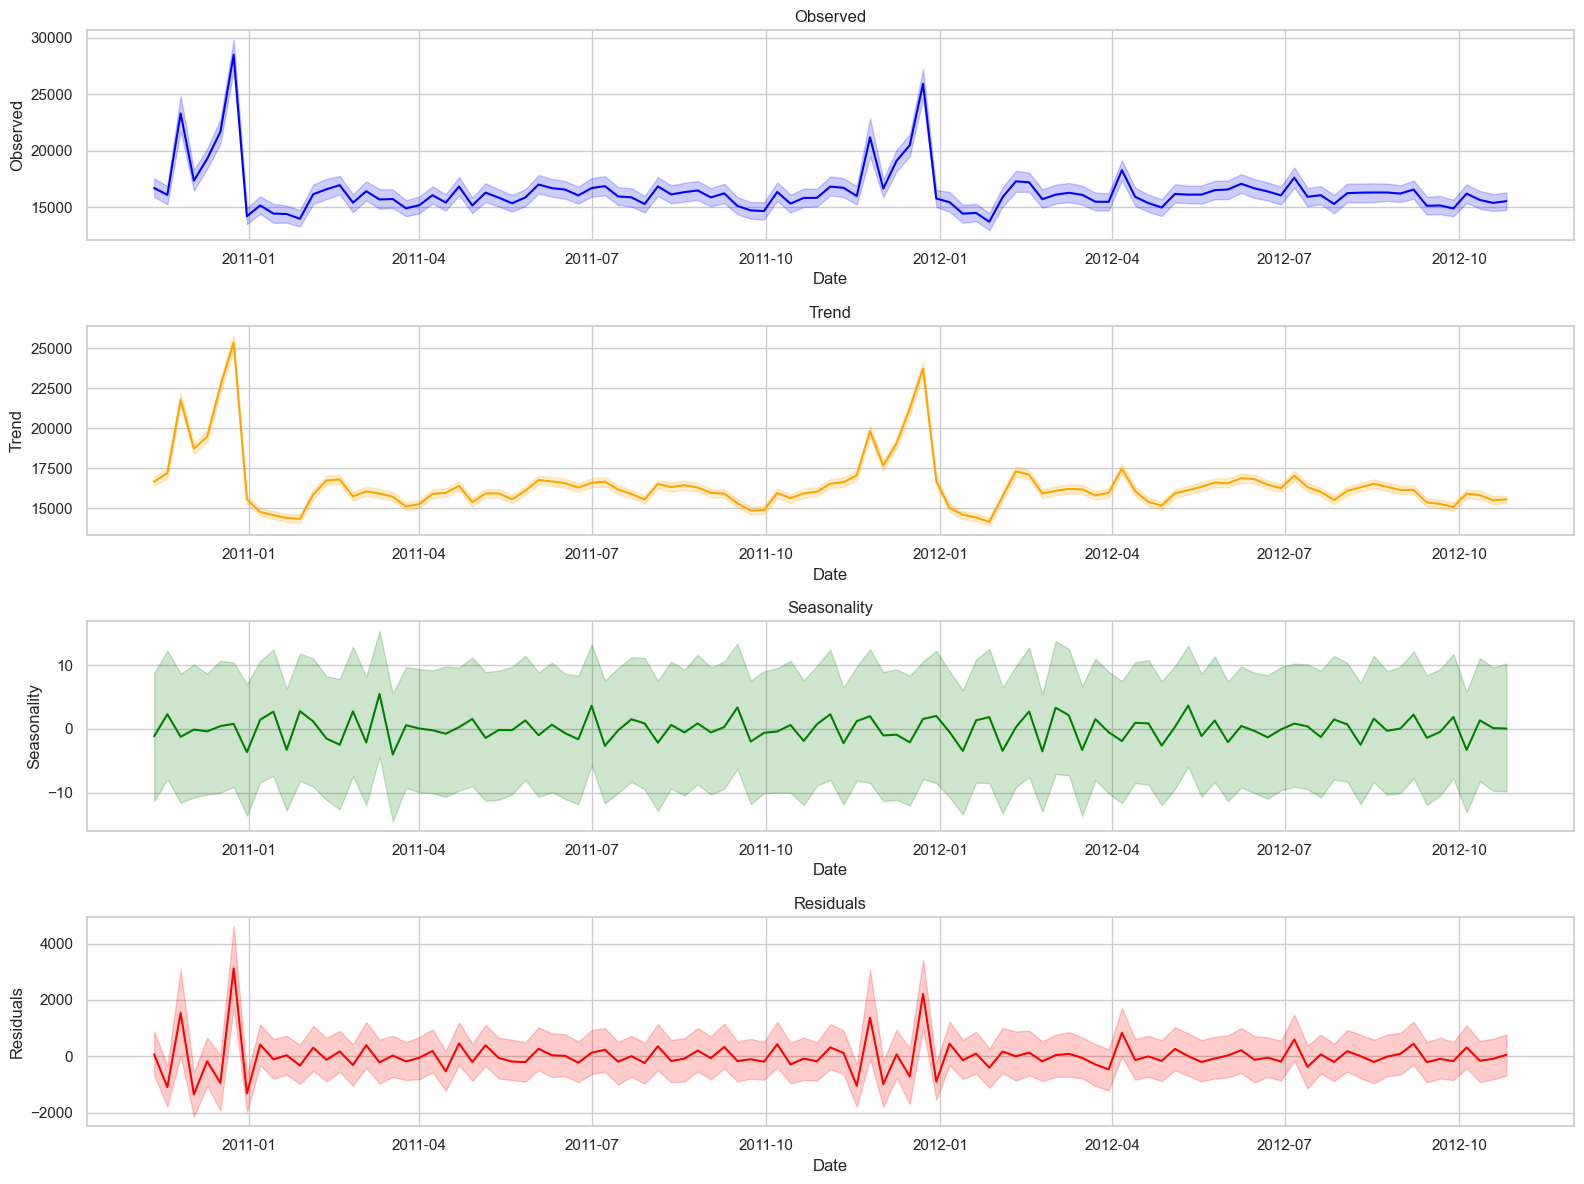

In [151]:

# for seasonal observation
sales=sm.tsa.seasonal_decompose(df["Weekly_Sales"],model="additive",period=52)

# df for decomposition
decomp_df=pd.DataFrame({
    "Date":df["Date"],
    "Observed":sales.observed,
    "Trend":sales.trend,
    "Seasonality":sales.seasonal,
    "Residuals":sales.resid
})

fig,axes=plt.subplots(4,1,figsize=(16,12))
sns.lineplot(data=decomp_df,x="Date",y="Observed",ax=axes[0],color="blue")
axes[0].set_title("Observed")

sns.lineplot(data=decomp_df,x="Date",y="Trend",ax=axes[1],color="orange")
axes[1].set_title("Trend")

sns.lineplot(data=decomp_df,x="Date",y="Seasonality",ax=axes[2],color="green")
axes[2].set_title("Seasonality")

sns.lineplot(data=decomp_df,x="Date",y="Residuals",ax=axes[3],color="red")
axes[3].set_title("Residuals")

plt.tight_layout()
plt.show()

### 10. Rolling Averages

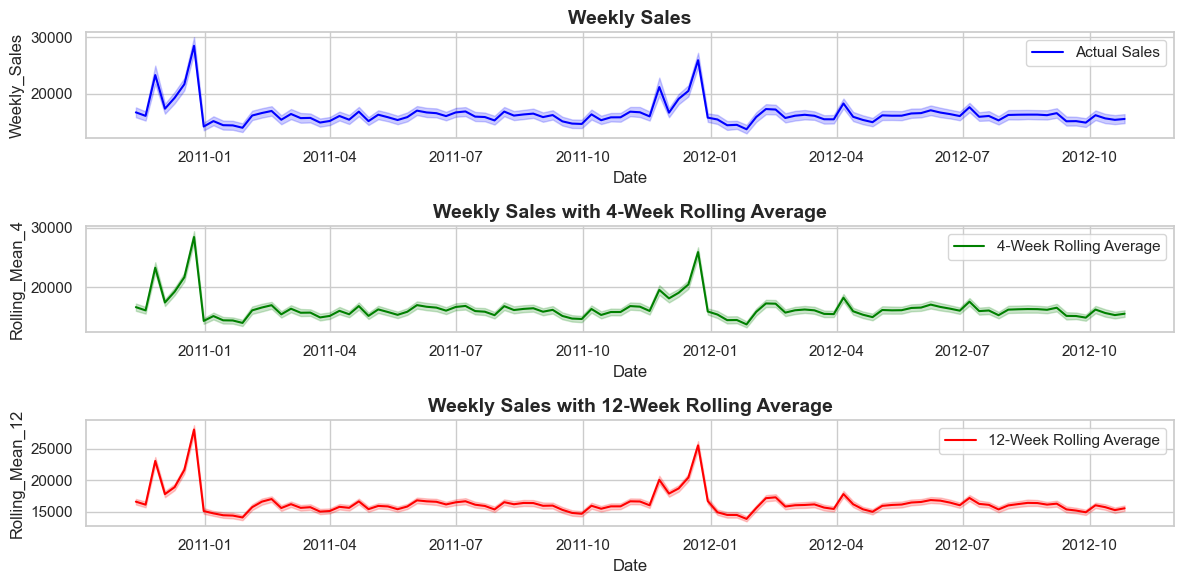

In [155]:
df['Rolling_Mean_4']=df['Weekly_Sales'].rolling(window=4).mean()
df['Rolling_Mean_12']=df['Weekly_Sales'].rolling(window=12).mean()

sns.set(style="whitegrid")
plt.figure(figsize=(12,6))
plt.subplot(3,1,1)
sns.lineplot(x="Date",y="Weekly_Sales",data=df,color="blue",label="Actual Sales")
plt.title("Weekly Sales",fontsize=14,fontweight="bold")
plt.legend()

plt.subplot(3,1,2)
sns.lineplot(x="Date",y="Rolling_Mean_4",data=df,color="green",label="4-Week Rolling Average")
plt.title("Weekly Sales with 4-Week Rolling Average",fontsize=14,fontweight="bold")
plt.legend()

plt.subplot(3,1,3)
sns.lineplot(x="Date",y="Rolling_Mean_12",data=df,color="red",label="12-Week Rolling Average")
plt.title("Weekly Sales with 12-Week Rolling Average",fontsize=14,fontweight="bold")
plt.legend()

plt.tight_layout()
plt.show()


### 11. Visualizing Training Models

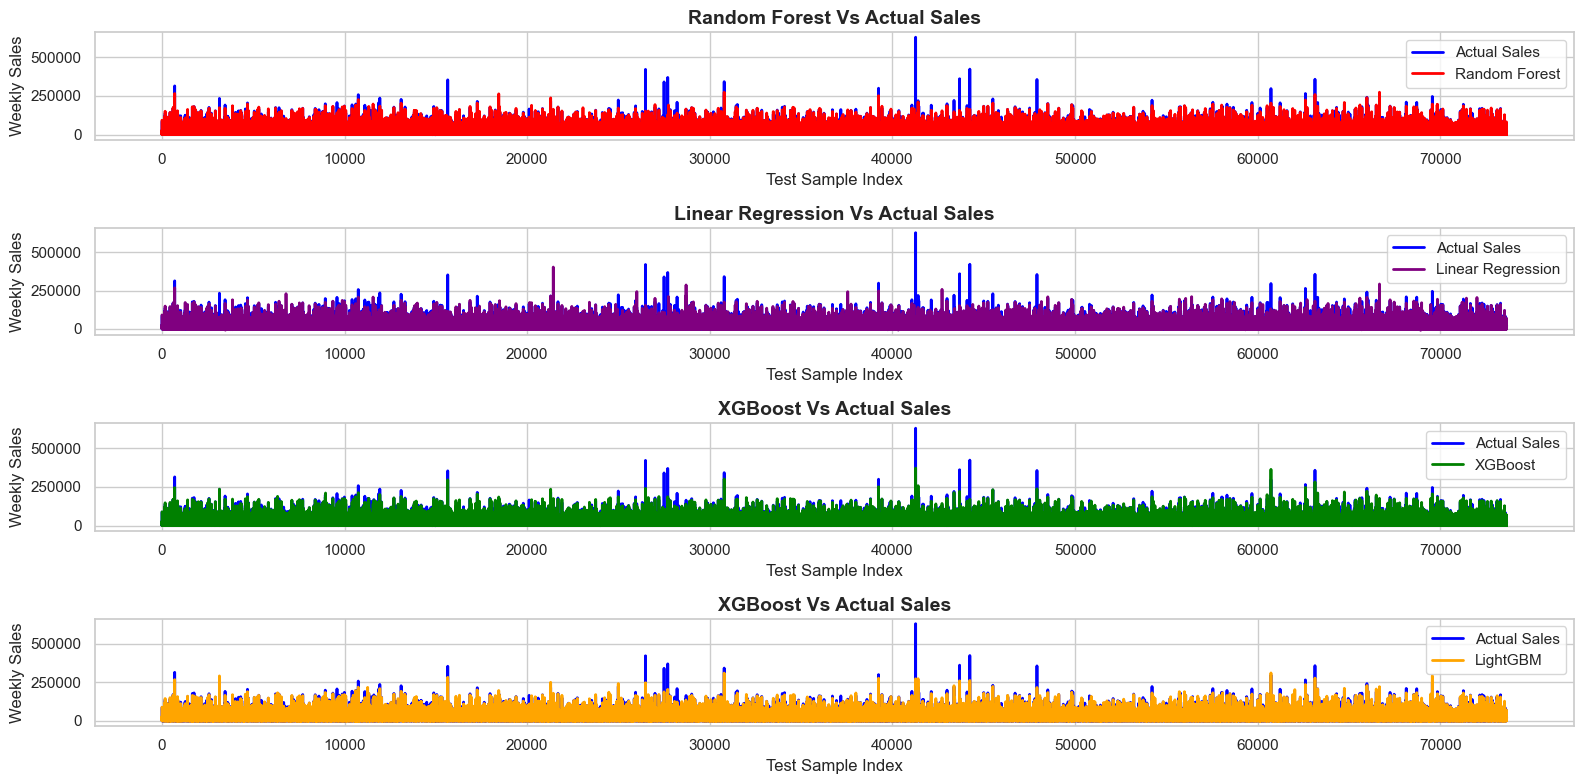

In [ ]:
# Just use sequential index for test set
test_time = range(len(y_test))

plt.figure(figsize=(16,8))
plt.subplot(4,1,1)
plt.plot(test_time,y_test,label="Actual Sales",color="blue",linewidth=2)
plt.plot(test_time,y_pred_randf,label="Random Forest",color="red",linewidth=2)
plt.legend()
plt.title("Random Forest Vs Actual Sales",fontsize=14,fontweight="bold")
plt.xlabel("Test Sample Index")
plt.ylabel("Weekly Sales")

plt.subplot(4,1,2)
plt.plot(test_time,y_test,label="Actual Sales",color="blue",linewidth=2)
plt.plot(test_time,y_pred_lr,label="Linear Regression",color="purple",linewidth=2)
plt.legend()
plt.title("Linear Regression Vs Actual Sales",fontsize=14,fontweight="bold")
plt.xlabel("Test Sample Index")
plt.ylabel("Weekly Sales")

plt.subplot(4,1,3)
plt.plot(test_time,y_test,label="Actual Sales",color="blue",linewidth=2)
plt.plot(test_time,y_pred_xgb,label="XGBoost",color="green",linewidth=2)
plt.legend()
plt.title("XGBoost Vs Actual Sales",fontsize=14,fontweight="bold")
plt.xlabel("Test Sample Index")
plt.ylabel("Weekly Sales")

plt.subplot(4,1,4)
plt.plot(test_time,y_test,label="Actual Sales",color="blue",linewidth=2)
plt.plot(test_time,y_pred_lgbm,label="LightGBM",color="orange",linewidth=2)
plt.legend()
plt.title("XGBoost Vs Actual Sales",fontsize=14,fontweight="bold")
plt.xlabel("Test Sample Index")
plt.ylabel("Weekly Sales")

plt.tight_layout()
plt.show()


### 12. Outcomes

In [2]:
print("---- SUMMARY STATISTICS -----\n")

print("Model Performance:\n")
print("Random Forest RMSE: 5071.65 | MAE: 1679.83 | R²: 0.953")
print("Linear Regression RMSE: 7154.73 | MAE: 2400.23 | R²: 0.906")
print("XGBoost RMSE: 4194.23 | MAE: 1659.77 | R²: 0.968")
print("LightGBM RMSE: 4117.63 | MAE: 1677.42 | R²: 0.969")
print("\nBest Model: LightGBM (R² = 0.9689)\n")

print("=== Feature Importance Highlights ===\n")

print("Random Forest:")
print("  → lag_1           : 81%     (Most predictive past sales)")
print("  → lag_4           : 12.7%   (4-week lag)")
print("  → week_of_year    : 1.16%   (Seasonal weekly pattern)")
print("  → lag_40          : 1.08%   (40-week lag)")
print("  → MarkDown3       : 0.66%   (Promotional discount)")
print("  → rolling_mean_10 : 0.48%   (10-week moving average)")
print("  → Other features contribute <0.5%\n")

print("Linear Regression:")
print("  → Fuel_Price_Change : 4001   (Impact of fuel price changes)")
print("  → CPI_Change        : 3940   (Effect of CPI changes)")
print("  → month             : 1051   (Monthly seasonality)")
print("  → is_fall/spring/summer : 530/458/79   (Seasonal indicators)")
print("  → week_of_year      : 199    (Weekly trend)")
print("  → year              : 68     (Long-term trend)")
print("  → Other features have smaller impact\n")

print("XGBoost:")
print("  → lag_1           : 0.652  (Most important lag)")
print("  → lag_4           : 0.141  (4-week lag)")
print("  → year            : 0.037  (Long-term trend)")
print("  → week_of_year    : 0.014  (Weekly seasonality)")
print("  → MarkDown3       : 0.017  (Promotional discount)")
print("  → rolling_mean_10 : 0.014  (10-week moving average)")
print("  → Dept, month, CPI, Unemployment, Fuel_Price : smaller importance\n")

print("LightGBM:")
print("  → lag_1           : 502    (Past sales strongest predictor)")
print("  → week_of_year    : 444    (Weekly seasonal effect)")
print("  → Dept            : 378    (Department-specific differences)")
print("  → lag_4 / lag_40  : 306 / 291   (Past sales lags)")
print("  → MarkDown3       : 154    (Promotional discount)")
print("  → month           : 119    (Monthly seasonality)")
print("  → rolling_mean_10 / rolling_mean_20 : 103 / 80   (Moving averages)")
print("  → Other features : moderate to small importance")

print("Rolling Averages Insights:\n")
print("4-week rolling mean smooths short-term fluctuations")
print("12-week rolling mean captures long-term seasonal trends\n")

print("Seasonal Decomposition Observations:\n")
print("Trend: Shows gradual growth in sales over time")
print("Seasonality: Weekly/annual patterns clearly visible")
print("Residuals: Mostly centered around zero, indicating modelable patterns in trend and seasonality")


---- SUMMARY STATISTICS -----

Model Performance:

Random Forest RMSE: 5071.65 | MAE: 1679.83 | R²: 0.953
Linear Regression RMSE: 7154.73 | MAE: 2400.23 | R²: 0.906
XGBoost RMSE: 4194.23 | MAE: 1659.77 | R²: 0.968
LightGBM RMSE: 4117.63 | MAE: 1677.42 | R²: 0.969

Best Model: LightGBM (R² = 0.9689)

=== Feature Importance Highlights ===

Random Forest:
  → lag_1           : 81%     (Most predictive past sales)
  → lag_4           : 12.7%   (4-week lag)
  → week_of_year    : 1.16%   (Seasonal weekly pattern)
  → lag_40          : 1.08%   (40-week lag)
  → MarkDown3       : 0.66%   (Promotional discount)
  → rolling_mean_10 : 0.48%   (10-week moving average)
  → Other features contribute <0.5%

Linear Regression:
  → Fuel_Price_Change : 4001   (Impact of fuel price changes)
  → CPI_Change        : 3940   (Effect of CPI changes)
  → month             : 1051   (Monthly seasonality)
  → is_fall/spring/summer : 530/458/79   (Seasonal indicators)
  → week_of_year      : 199    (Weekly trend)


#### LightGBM and XGBoost performed best due to their ability to capture non-linear patterns and interactions. Lagged sales and rolling averages were the most important predictors, showing that historical sales strongly drive forecasts. Random Forest also performed well but slightly below LightGBM. Linear Regression, while interpretable, struggled with extreme sales peaks. Seasonal decomposition confirms strong weekly and yearly patterns, aligning with rolling average trends.